In [1]:
import numpy as np
import datetime
import pandas as pd
import random

In [2]:
#X=pd.read_csv('nifty.csv')
#len(X)

In [3]:
def data1():
    X=pd.read_csv('tempcnn.csv')
    X = X.iloc[20:]  # Keep rows from index 19 onwards (0-based index)
    # Ensure 'Open' and 'Close' are treated as numeric
    X['cashopen']=0
    X['cash']=0
    # Ensure columns have float dtype before assignment
    X['cashopen'] = X['cashopen'].astype(float)
    X['cash'] = X['cash'].astype(float)
    X['action']=""
    X['diff']=""
    X['quantity']=""
    return X
    

In [4]:
X=data1()

In [5]:
print(len(X))

2825


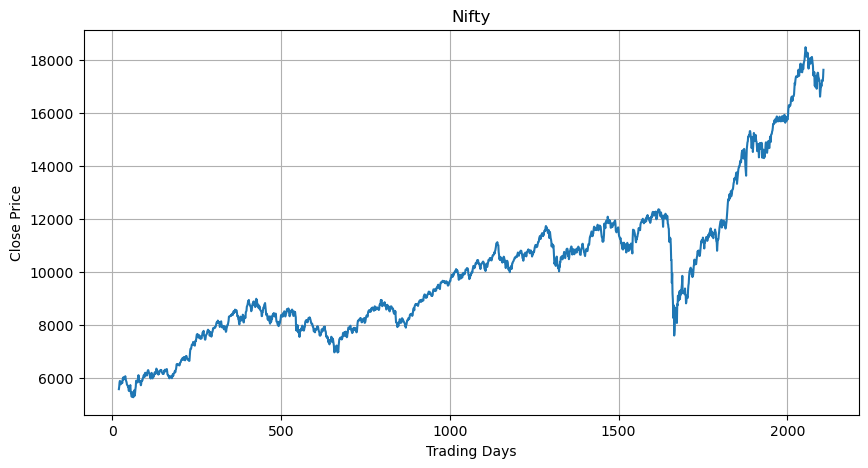

In [6]:
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure()
ax=X.loc[1:2107,'Close'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("Close Price")
plt.show()
fig.savefig('nifty_close.png')

In [7]:
X.head()

,Unnamed: 0,index,Close,High,Low,Open,Volume,date,weekday,month,...,PVT,Target,cnnstate,p_co,state2d,cashopen,cash,action,diff,quantity
20,20,120,5588.700195,5635.250000,5579.350098,5627.950195,160100,26-06-2013,0.50,0.454545,...,0.361818,0,2.0,1.060175,5.0,0.0,0.0,,,
21,21,121,5682.350098,5699.350098,5630.950195,5647.950195,239000,27-06-2013,0.75,0.454545,...,0.368536,2,2.0,1.181728,5.0,0.0,0.0,,,
22,22,122,5842.200195,5852.950195,5749.500000,5749.500000,214400,28-06-2013,1.00,0.454545,...,0.378654,2,2.0,-0.138648,2.0,0.0,0.0,,,
23,23,123,5898.850098,5904.350098,5822.200195,5834.100098,144800,01-07-2013,0.00,0.545455,...,0.381010,2,0.0,-0.226317,0.0,0.0,0.0,,,
24,24,124,5857.549805,5898.799805,5852.299805,5885.500000,145700,02-07-2013,0.25,0.545455,...,0.379298,0,0.0,-0.778476,0.0,0.0,0.0,,,


In [8]:
X['state2d'].value_counts()

state2d
3.0    840
5.0    773
0.0    401
2.0    356
4.0    314
1.0    140
Name: count, dtype: int64

In [9]:
#X.head()

In [10]:
def getState(t):
    t = int(t)
    return(X['state2d'][t])  

In [11]:
class Agent:
    def __init__(self):
        self.epsilon = 1.0
        self.gamma = 0.618
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.01
        self.Q = np.matrix(np.zeros([6,3]))
        self.learning_rate=0.03
        
    def getAction(self,state):
        state = int(state)
        a=[1,0,2]
        if np.random.rand() <= self.epsilon:
            return random.choice(a)
        return np.argmax(self.Q[state,])  
    
    # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
    def update(self,state,action,reward,next_state,next_action):
        state = int(state)
        action = int(action)
        next_state = int(next_state)
        self.Q[state,action]= self.Q[state,action] + self.learning_rate * (reward + self.gamma * np.max(self.Q[next_state, :])
                                                                - self.Q[state,action])

        

In [13]:
episode_count=100
agent=Agent()
agent.Q
m1=0
m2=0
for e in range(1,episode_count+1):
    X=data1()
    
    data_length_start=21
    data_length=2107
    state = getState(data_length_start-1)
    action = agent.getAction(state)
    
  
    capital=X.loc[data_length_start,'Open']*10
    margin=X.loc[data_length_start,'Open']*10
    #X.loc[2,'cashopen']=margin 
    X.loc[2, 'cashopen'] = float(margin)
    brok_rate=0.0000
    #brok_rate=0.0
    
    print("Episod {}/{}".format(e,episode_count))
    count=0
    for t in range(data_length_start,data_length):
                
        reward=0                        
         
        if action == 1:
            X.loc[t,'cashopen']=float(margin)
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=quantity
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=float(margin)         
            
            #print('Long: open price @',X.loc[t,'Open'],'Close price @',X.loc[t,'Close'], 'profit=',tprofit)
            X.loc[t,'action']="long"
            X.loc[t,'diff']=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Close'])-np.log(X.loc[t,'Open']+tbrokerage)),0)
            
       
        elif action == 2:
            X.loc[t,'cashopen']=float(margin) 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=(-quantity)
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            #print('in Short')
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=float(margin)         
            last_action='Short'
            #print('Short: Close price @',X.loc[t,'Close'],'Open price @',X.loc[t,'Open'], 'profit=',tprofit)
            X.loc[t,'action']="short"
            X.loc[t,'diff']=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Open'])-np.log(X.loc[t,'Close']+tbrokerage)),0)
           
        else:
            X.loc[t,'cash']=margin
            X.loc[t,'action']="Hold"
            X.loc[t,'diff']=0
            reward=0                                  
              
        next_state=int(getState(t))
        next_action=agent.getAction(next_state)
        agent.update(state,action,reward,next_state,next_action)
        state=next_state
        action=next_action
        
        if t==data_length-1:
                print("\n***********************\n",t)
                print("Profit is ",(margin-capital))
                print("Initial Capital is ",capital)    
                print("Current Capital is ",margin)
                roi=((margin-capital)/capital)*100
                print("%ROI is ",roi)
                bnh=((X.loc[t,'Close']-X.loc[data_length_start,'Open'])/X.loc[data_length_start,'Open'])*100
                print("% Buy and Hold=",bnh)
                print("count",count)
                print("qtable",agent.Q)
                print("epsilon",agent.epsilon)
                print("--------------------------------")
                       
        if (agent.epsilon > agent.epsilon_min) and e>1:
                       agent.epsilon *= agent.epsilon_decay
                       
    
    m3=roi
    if m3>m2:
        m1=e
        m2=m3
    #To save model  
    if e%20==0:
        np.save('rl/Qtable'+ str(e)+str('.npy'), agent.Q)
        np.save('rl/epsilon'+ str(e)+str('.npy'), agent.epsilon)
        np.save('rl/gamma'+ str(e)+str('.npy'), agent.gamma)
        np.save('rl/learning_rate'+ str(e)+str('.npy'), agent.learning_rate)
        X.to_csv('csv1/AfterTrain'+str(e)+str('.csv'))
print("e={},roi={}".format(m1,m2))

Episod 1/100

***********************
 2106
Profit is  -12018.519609999923
Initial Capital is  56479.501950000005
Current Capital is  44460.98234000008
%ROI is  -21.279436246869952
% Buy and Hold= 207.2628153726132
count 1387
qtable [[0.00624506 0.00600607 0.01510798]
 [0.00444967 0.00307803 0.00332018]
 [0.00628581 0.0143254  0.00558981]
 [0.00733386 0.00733182 0.0157829 ]
 [0.00658216 0.00583345 0.00593156]
 [0.00671808 0.01322771 0.00717795]]
epsilon 1.0
--------------------------------
Episod 2/100

***********************
 2106
Profit is  4228698440.1074505
Initial Capital is  56479.501950000005
Current Capital is  4228754919.6094003
%ROI is  7487138.33179871
% Buy and Hold= 207.2628153726132
count 1683
qtable [[0.00706087 0.0066869  0.02069852]
 [0.00943313 0.00329871 0.00373856]
 [0.00713471 0.01838279 0.00678237]
 [0.00789146 0.00801975 0.0187794 ]
 [0.01039562 0.0067096  0.0063275 ]
 [0.00732001 0.0163049  0.00755971]]
epsilon 0.00998645168764533
------------------------------

In [14]:
agent.Q

matrix([[0.0101883 , 0.01058629, 0.02087058],
        [0.01013669, 0.00717842, 0.00774742],
        [0.0099702 , 0.01860253, 0.0098077 ],
        [0.01000126, 0.01015147, 0.0188837 ],
        [0.00888368, 0.0087909 , 0.01094535],
        [0.00970645, 0.01637709, 0.00989782]])

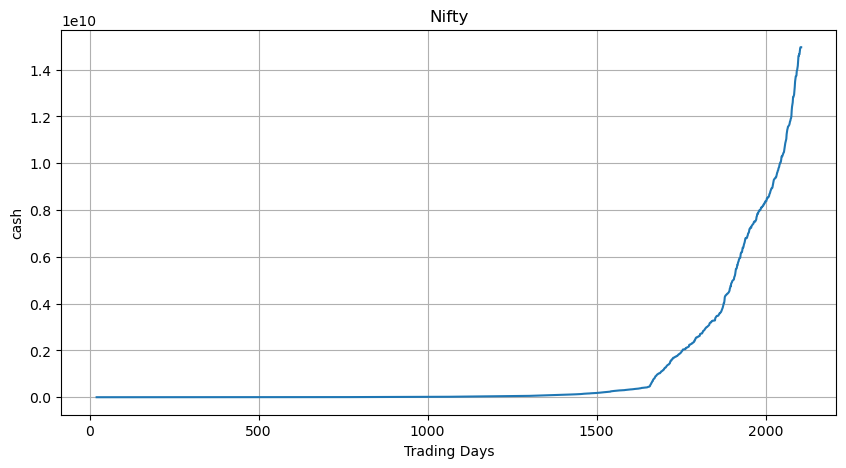

In [15]:
%matplotlib inline
fig = plt.figure()
ax=X.loc[data_length_start:data_length-2,'cash'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("cash")
plt.show()